In [1]:
import sys
sys.path.append("../..")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn import GaussianNLLLoss
from scipy.optimize import minimize_scalar
from scipy.stats import norm
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from deep_uncertainty.evaluation.calibration import (compute_average_calibration_score,
                                    plot_regression_calibration_curve)
from deep_uncertainty.models.regressors import GaussianDNN
from deep_uncertainty.toy.gen_data import generate_gaussian_data
from deep_uncertainty.utils.model_utils import evaluate_gaussian_dnn, train_gaussian_dnn

In [2]:
def gaussian_nll(targets, mean, logvar):
    return 0.5 * (torch.exp(-logvar) * (targets - mean)**2 + logvar).mean()

def parametrized_gaussian_nll(targets, mean, logvar, tau):
    """NLL for Gaussian with standard deviation of (tau * sigma)."""
    loss = GaussianNLLLoss()
    var = tau**2 * np.exp(logvar)
    return loss(torch.Tensor(mean), torch.Tensor(targets), torch.Tensor(var)).numpy()

def visualize_regression_model_on_test_with_confidence_regions(test_x, test_y, posterior):
    test_x = test_x.squeeze()
    plt.figure(figsize=(10, 6))
    plt.scatter(test_x, test_y, alpha=0.1, label="Generated Data")
    plt.plot(test_x, posterior.kwds['loc'], label="Predicted Mean", color='r', linestyle='-', linewidth=2)
    plt.fill_between(test_x, posterior.ppf(0.025), posterior.ppf(0.972), color='r', alpha=0.2, label="95% confidence interval")

    plt.axvline(x=-5, color='g', linestyle='--', linewidth=2, label="Training Data Ends")
    plt.axvline(x=5, color='g', linestyle='--', linewidth=2)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Gaussian DNN Regression')
    plt.legend()
    plt.show()

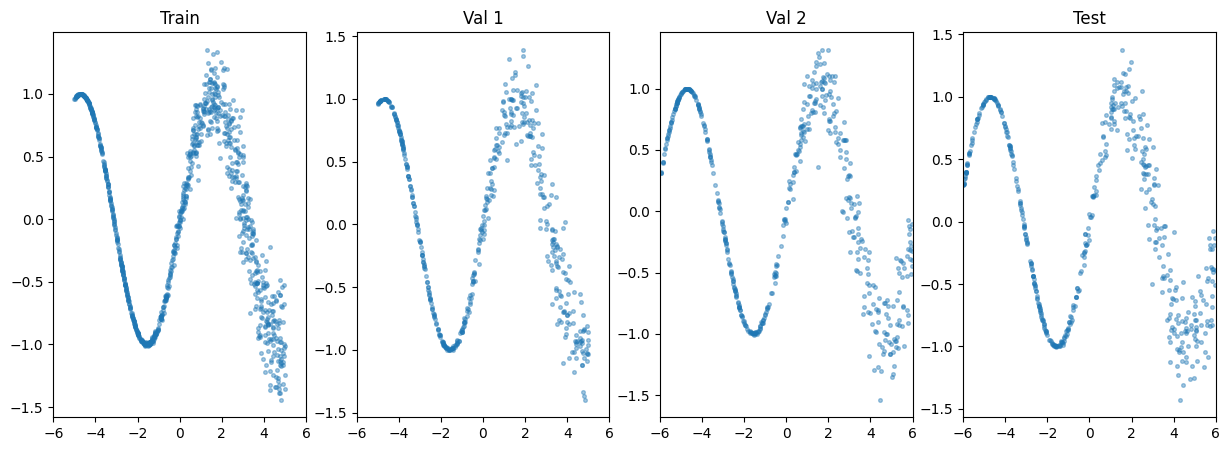

In [3]:
train_x, train_y = generate_gaussian_data(1000, x_min=-5, x_max=5)
val_1_x, val_1_y = generate_gaussian_data(500, x_min=-5, x_max=5)
val_2_x, val_2_y = generate_gaussian_data(500, x_min=-6, x_max=6)
test_x, test_y = generate_gaussian_data(500, x_min=-6, x_max=6)

# Sort test and val sets by the x input (needed for proper mean calibration calculation and confidence interval plotting).
test_order = np.argsort(test_x)
val_1_order = np.argsort(val_1_x)
val_2_order = np.argsort(val_2_x)
test_x, test_y = test_x[test_order], test_y[test_order]
val_1_x, val_1_y = val_1_x[val_1_order], val_1_y[val_1_order]
val_2_x, val_2_y = val_2_x[val_2_order], val_2_y[val_2_order]

fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].set_title("Train")
axs[0].scatter(train_x, train_y, alpha=0.4, s=7)

axs[1].set_title("Val 1")
axs[1].scatter(val_1_x, val_1_y, alpha=0.4, s=7)

axs[2].set_title("Val 2")
axs[2].scatter(val_2_x, val_2_y, alpha=0.4, s=7)

axs[3].set_title("Test")
axs[3].scatter(test_x, test_y, alpha=0.4, s=7)

[ax.set_xlim(-6, 6) for ax in axs]
plt.show()

In [4]:
train_x = torch.tensor(train_x, dtype=torch.float32).unsqueeze(1)
train_y = torch.tensor(train_y, dtype=torch.float32).unsqueeze(1)
test_x = torch.tensor(test_x, dtype=torch.float32).unsqueeze(1)
test_y = torch.tensor(test_y, dtype=torch.float32).unsqueeze(1)
val_1_x = torch.tensor(val_1_x, dtype=torch.float32).unsqueeze(1)
val_1_y = torch.tensor(val_1_y, dtype=torch.float32).unsqueeze(1)
val_2_x = torch.tensor(val_2_x, dtype=torch.float32).unsqueeze(1)
val_2_y = torch.tensor(val_2_y, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(train_x, train_y)
test_dataset = TensorDataset(test_x, test_y)
val_1_dataset = TensorDataset(val_1_x, val_1_y)
val_2_dataset = TensorDataset(val_2_x, val_2_y)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_1_loader = DataLoader(val_1_dataset, batch_size=32, shuffle=False)
val_2_loader = DataLoader(val_2_dataset, batch_size=32, shuffle=False)

Training Gaussian DNN: 100%|██████████| 50/50 [00:01<00:00, 40.26epoch/s, Train Loss=-1.8554, Val Loss=-1.8844]


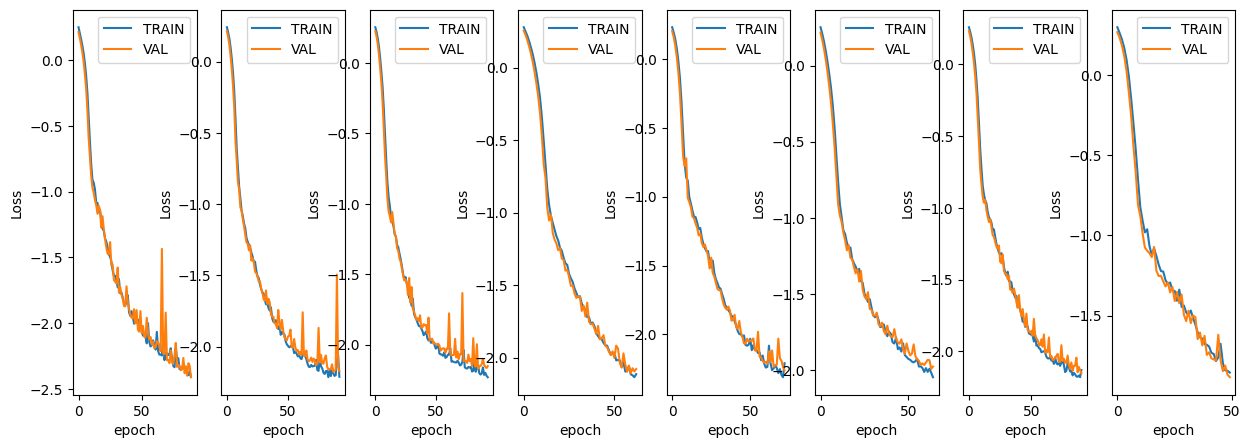

In [5]:
num_models_to_ensemble = 8
models = []
fig, axs = plt.subplots(1, num_models_to_ensemble, figsize=(15, 5))

for _, ax in zip(range(num_models_to_ensemble), axs.ravel()):
    lr = 1e-4
    num_epochs = np.random.randint(25, 100)

    gaussian_dnn_model = GaussianDNN()
    optimizer = Adam(gaussian_dnn_model.parameters(), lr=lr)
    progress_bar = tqdm(range(num_epochs), desc="Training Gaussian DNN", unit="epoch")
    trn_losses = []
    val_losses = []
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    for epoch in progress_bar:
        train_loss = train_gaussian_dnn(train_loader, gaussian_dnn_model, optimizer, device)
        val_loss = evaluate_gaussian_dnn(val_1_loader, gaussian_dnn_model, device)
        
        trn_losses.append(train_loss)
        val_losses.append(val_loss)
        
        progress_bar.set_postfix({"Train Loss": f"{train_loss:.4f}", "Val Loss": f"{val_loss:.4f}"})

    models.append(gaussian_dnn_model)

    ax.plot(np.arange(num_epochs), trn_losses, label='TRAIN')
    ax.plot(np.arange(num_epochs), val_losses, label='VAL')
    ax.set_xlabel("epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.show()

In [6]:
def get_gaussian_conflation_posterior(models: list, input: torch.Tensor):
    """Take in a list of Gaussian DNNs and return a probability distribution over the output space."""
    means = np.zeros(shape=(len(models), len(input.flatten())))
    sigmas = np.zeros(shape=(len(models), len(input.flatten())))

    for i, model in enumerate(models):
        mu, logvar = model(test_x)
        mu = mu.squeeze().detach().numpy()
        stdev = np.sqrt(np.exp(logvar.squeeze().detach().numpy()))
        means[i, :] = mu
        sigmas[i, :] = stdev

    mu_numerator = (means / (sigmas ** 2)).sum(axis=0)
    mu_denominator = np.power(sigmas, -2).sum(axis=0)
    sigma_denominator = np.power(sigmas, -2).sum(axis=0)
    mu = mu_numerator / mu_denominator
    sigma = np.power(sigma_denominator, -1)
    conflated_posterior = norm(loc=mu, scale=sigma)

    return conflated_posterior


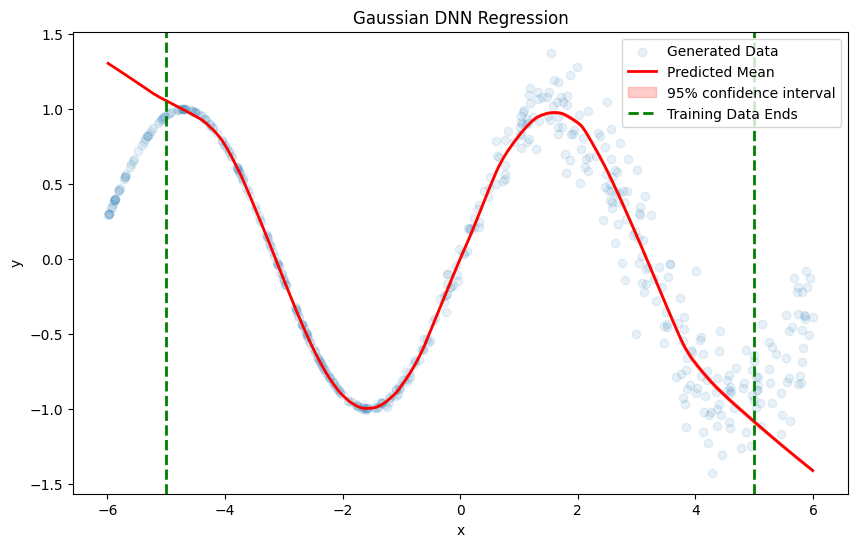

In [7]:
test_posterior = get_gaussian_conflation_posterior(models, test_x)

visualize_regression_model_on_test_with_confidence_regions(test_x, test_y, test_posterior)

With a conflation approach, we get a VERY overconfident model. We are probably breaking the independence assumptions of the conflation theory since the networks do not represent a very diverse group of probabilistic models. Each individual ensemble member is overconfidence and highly similar to the next, hence the uncertainty in our conflation almost completely vanishes.

It may be that we get more diversity of model when we expand beyond this simple setting.

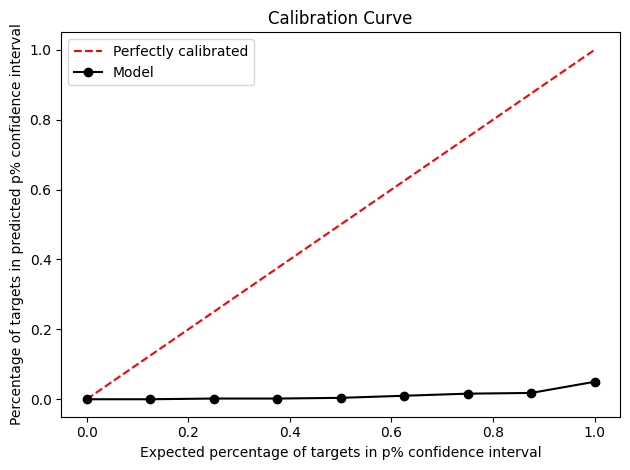

0.016631359606985918

In [8]:
plot_regression_calibration_curve(test_y.squeeze().detach().numpy(), test_posterior)
compute_average_calibration_score(test_y.squeeze().detach().numpy(), test_posterior)

In [9]:
def calibration_loss(targets: torch.Tensor, posterior: norm, tau: float):
    copy = norm(loc=posterior.kwds['loc'], scale=tau*posterior.kwds['scale'])
    return -compute_average_calibration_score(targets.squeeze().detach().numpy(), copy)

In [10]:
val_1_posterior = get_gaussian_conflation_posterior(models, val_1_x)

result = minimize_scalar(lambda tau: calibration_loss(val_1_y, val_1_posterior, tau), bounds=[1e-4, 250])
tau = result.x
print(f"Learned value of tau: {tau}")

recalibrated_test_posterior = norm(loc=test_posterior.kwds['loc'], scale=tau * test_posterior.kwds['scale'])

Learned value of tau: 191.21284874019162


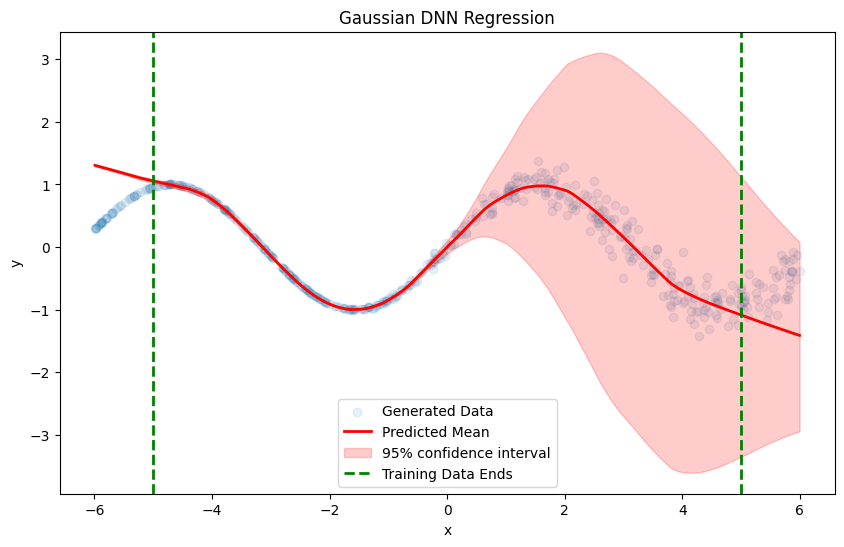

In [11]:
visualize_regression_model_on_test_with_confidence_regions(test_x, test_y, recalibrated_test_posterior)

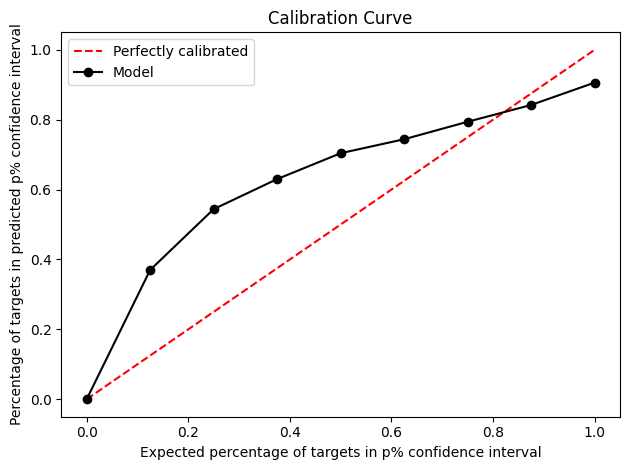

0.688637609122053

In [12]:
plot_regression_calibration_curve(test_y.squeeze().detach().numpy(), recalibrated_test_posterior)
compute_average_calibration_score(test_y.squeeze().detach().numpy(), recalibrated_test_posterior)

In [13]:
val_2_posterior = get_gaussian_conflation_posterior(models, val_2_x)

result = minimize_scalar(lambda tau: calibration_loss(val_2_y, val_2_posterior, tau), bounds=[1e-4, 250])
tau = result.x
print(f"Learned value of tau: {tau}")

recalibrated_test_posterior = norm(loc=test_posterior.kwds['loc'], scale=tau * test_posterior.kwds['scale'])

Learned value of tau: 154.51386207281294


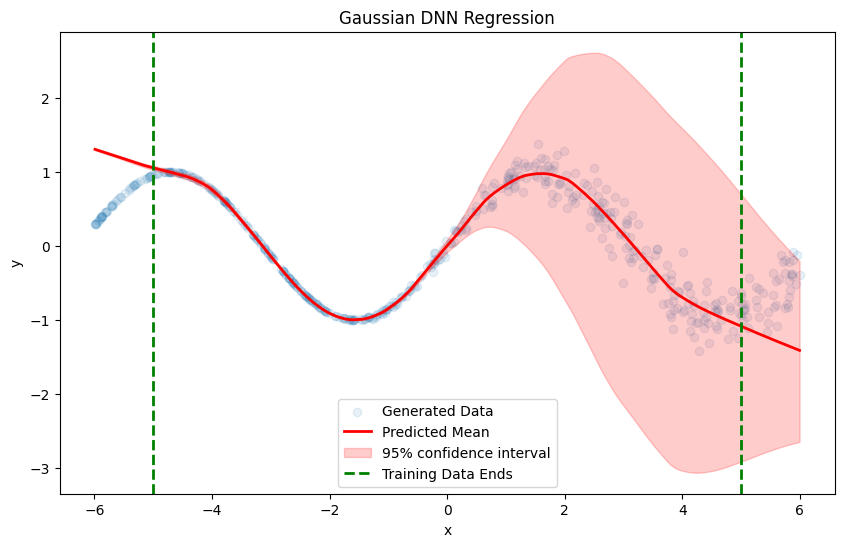

In [14]:
visualize_regression_model_on_test_with_confidence_regions(test_x, test_y, recalibrated_test_posterior)

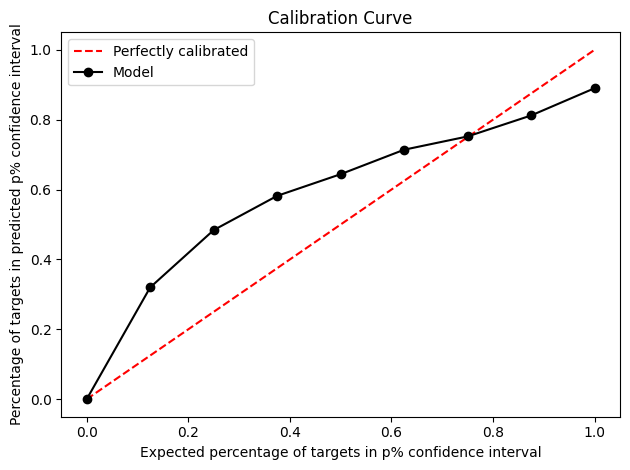

0.7429866740695683

In [15]:
plot_regression_calibration_curve(test_y.squeeze().detach().numpy(), recalibrated_test_posterior)
compute_average_calibration_score(test_y.squeeze().detach().numpy(), recalibrated_test_posterior)